In [1]:
import os

# Habilita leitura de OpenEXR pelo OpenCV
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

import subprocess

import cv2
import numpy as np
import matplotlib.pyplot as plt

import trimesh
import OpenEXR
import Imath


PBRT_WSL_PATH = "/mnt/c/Users/Wemerson/pbrt-v4/build/pbrt"


print("Mesh:", os.path.exists("ClayPot.ply"))
print("Reference:", os.path.exists("vase_reference.tif"))

teste = subprocess.run(
    [
        "wsl",
        PBRT_WSL_PATH,
        "--help"
    ],
    capture_output=True,
    text=True
)


print("PBRT funcionando:",
      "usage: pbrt" in teste.stdout)


Mesh: True
Reference: True
PBRT funcionando: False


In [2]:
def windows_to_wsl(path):

    path = os.path.abspath(path)

    return (
        "/mnt/c" +
        path.replace("\\", "/")[2:]
    )


# teste
print(windows_to_wsl("temp_vessel_scene.pbrt"))

/mnt/c/Users/Wemerson/Documents/Backups/PIB15937_2025/OrenNayar (ipynb)/temp_vessel_scene.pbrt


In [3]:
scene_vessel = r'''
LookAt 
    0.0 0.3 0.055
    0 0 0.055
    0 0 1


Camera "perspective"
    "float fov" [35]


Sampler "halton"
    "integer pixelsamples" [16]


Integrator "path"
    "integer maxdepth" [5]


Film "rgb"
    "string filename" "vessel_render.exr"
    "integer xresolution" [800]
    "integer yresolution" [800]


WorldBegin


# Luz principal lateral/inclinada (Mais potente)
AttributeBegin
    Translate 0.35 0.40 0.20
    AreaLightSource "diffuse"
        "rgb L" [200 200 200]  # Aumentado de 80 para 200
    Shape "sphere"
        "float radius" [0.03]
AttributeEnd

# Luz de preenchimento (Para clarear o lado escuro)
AttributeBegin
    Translate -0.20 0.35 0.05
    AreaLightSource "diffuse"
        "rgb L" [60 60 60]    # Aumentado de 30 para 60
    Shape "sphere"
        "float radius" [0.02]
AttributeEnd


AttributeBegin

    MakeNamedMaterial "oren"

        "string type" "orennayar"

        "rgb reflectance" [0.7 0.4 0.2]

        "float sigma" [30]


    NamedMaterial "oren"


    Shape "plymesh"
        "string filename" "ClayPot.ply"


AttributeEnd
'''


with open("temp_vessel_scene.pbrt","w") as f:
    f.write(scene_vessel)

In [4]:
id="render_vessel_01"
scene_wsl = windows_to_wsl(
    "temp_vessel_scene.pbrt"
)


cmd = [
    "wsl",
    PBRT_WSL_PATH,
    scene_wsl
]


result = subprocess.run(
    cmd,
    capture_output=True,
    text=True
)


# print(result.stdout)
# print(result.stderr)


if result.returncode == 0:
    print("Render concluído com sucesso!")
else:
    print("Erro no PBRT. Código:", result.returncode)

Render concluído com sucesso!


In [5]:
filename = "vessel_render.exr"

exr = OpenEXR.InputFile(filename)

header = exr.header()

dw = header["dataWindow"]

width = dw.max.x - dw.min.x + 1
height = dw.max.y - dw.min.y + 1


pixel_type = Imath.PixelType(Imath.PixelType.FLOAT)


R = np.frombuffer(
    exr.channel("R", pixel_type),
    dtype=np.float32
).reshape(height, width)

G = np.frombuffer(
    exr.channel("G", pixel_type),
    dtype=np.float32
).reshape(height, width)

B = np.frombuffer(
    exr.channel("B", pixel_type),
    dtype=np.float32
).reshape(height, width)


img = np.stack(
    [R, G, B],
    axis=-1
)


print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())


shape: (800, 800, 3)
dtype: float32
min: 0.0
max: 0.515625


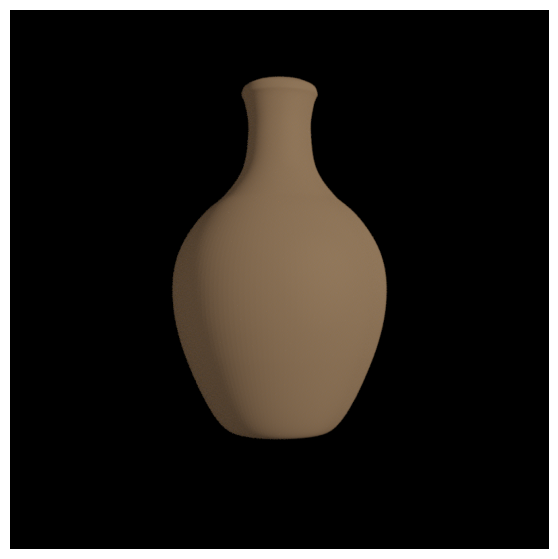

In [6]:
def show_exr(img):

    img_display = np.clip(img,0,None)

    # tone mapping HDR
    img_display = img_display / (1 + img_display)

    # linear -> sRGB aproximado
    img_display = img_display ** (1/2.2)

    plt.figure(figsize=(7,7))
    plt.imshow(img_display)
    plt.axis("off")
    plt.show()

show_exr(img)    

In [7]:
def render_vessel(r, g, b, sigma, output_filename):
    scene_description = f"""
    LookAt 
        0.0 0.3 0.055
        0 0 0.055
        0 0 1

    Camera "perspective"
        "float fov" [35]

    Sampler "halton"
        "integer pixelsamples" [16]

    Integrator "path"
        "integer maxdepth" [5]

    Film "rgb"
        "string filename" "{output_filename}"
        "integer xresolution" [400]
        "integer yresolution" [400]

    WorldBegin

    # Luz principal lateral
    AttributeBegin
        Translate 0.35 0.40 0.20
        AreaLightSource "diffuse"
            "rgb L" [200 200 200]
        Shape "sphere"
            "float radius" [0.03]
    AttributeEnd

    # Luz de preenchimento
    AttributeBegin
        Translate -0.20 0.35 0.05
        AreaLightSource "diffuse"
            "rgb L" [60 60 60]
        Shape "sphere"
            "float radius" [0.02]
    AttributeEnd

    AttributeBegin
        MakeNamedMaterial "oren"
            "string type" "orennayar"
            "rgb reflectance" [{r} {g} {b}]
            "float sigma" [{sigma}]

        NamedMaterial "oren"

        Shape "plymesh"
            "string filename" "ClayPot.ply"
    AttributeEnd
    """

    pbrt_file = f"temp_{output_filename}.pbrt"
    with open(pbrt_file, "w") as f:
        f.write(scene_description)

    cmd = ["wsl", PBRT_WSL_PATH, windows_to_wsl(pbrt_file)]
    subprocess.run(cmd, capture_output=True, text=True)


def load_exr_as_array(filename):
    exr = OpenEXR.InputFile(filename)
    header = exr.header()
    dw = header["dataWindow"]
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1
    pixel_type = Imath.PixelType(Imath.PixelType.FLOAT)

    R = np.frombuffer(
        exr.channel("R", pixel_type), dtype=np.float32
    ).reshape(height, width)
    G = np.frombuffer(
        exr.channel("G", pixel_type), dtype=np.float32
    ).reshape(height, width)
    B = np.frombuffer(
        exr.channel("B", pixel_type), dtype=np.float32
    ).reshape(height, width)

    return np.stack([R, G, B], axis=-1)

In [8]:
# Dicionário com os tipos de argila (Nome: [R, G, B])
materiais_argila = {
    "Terracota": [0.70, 0.35, 0.20],
    "Creme": [0.80, 0.75, 0.65],
    "Escura": [0.25, 0.18, 0.15],
}

sigmas_teste = [0.0, 20.0, 40.0, 60.0]
matriz_renders = {}

print("Iniciando renderizações da matriz...")
for nome_mat, rgb in materiais_argila.items():
    matriz_renders[nome_mat] = {}
    for s in sigmas_teste:
        out_name = f"vessel_{nome_mat}_sigma_{int(s)}.exr"
        render_vessel(rgb[0], rgb[1], rgb[2], s, out_name)
        matriz_renders[nome_mat][s] = load_exr_as_array(out_name)
        print(f"Renderizado: Argila {nome_mat} | sigma = {s}°")

print("Matriz concluída!")

Iniciando renderizações da matriz...
Renderizado: Argila Terracota | sigma = 0.0°
Renderizado: Argila Terracota | sigma = 20.0°
Renderizado: Argila Terracota | sigma = 40.0°
Renderizado: Argila Terracota | sigma = 60.0°
Renderizado: Argila Creme | sigma = 0.0°
Renderizado: Argila Creme | sigma = 20.0°
Renderizado: Argila Creme | sigma = 40.0°
Renderizado: Argila Creme | sigma = 60.0°
Renderizado: Argila Escura | sigma = 0.0°
Renderizado: Argila Escura | sigma = 20.0°
Renderizado: Argila Escura | sigma = 40.0°
Renderizado: Argila Escura | sigma = 60.0°
Matriz concluída!


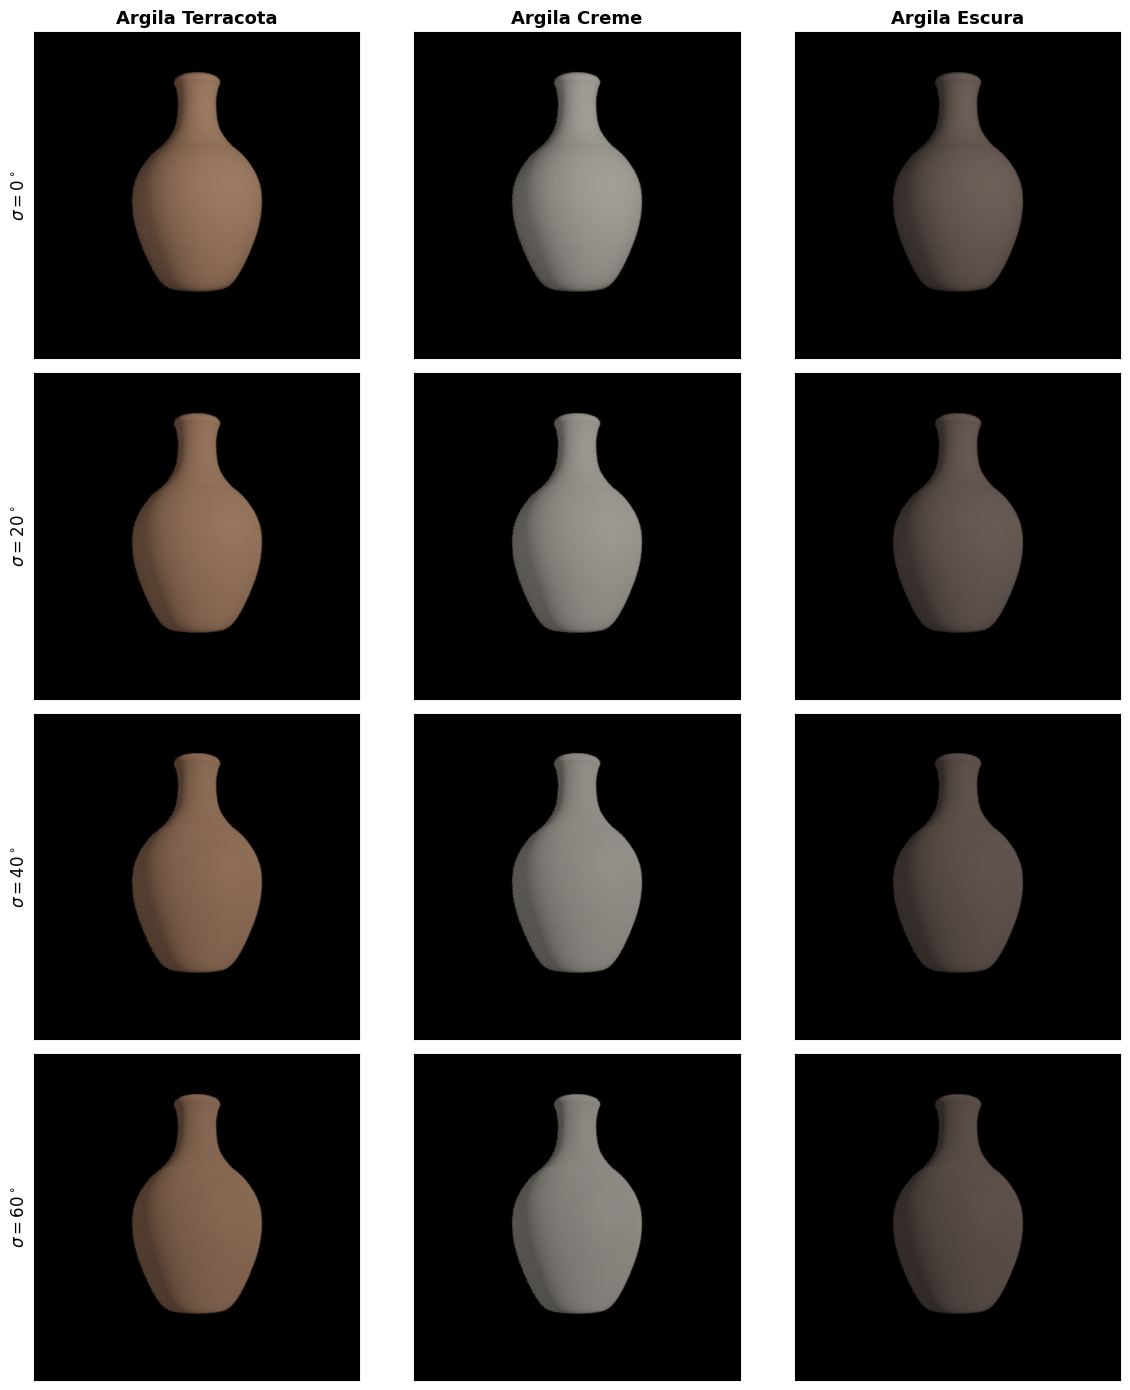

In [9]:
def process_for_display(img):
    img_disp = np.clip(img, 0, None)
    img_disp = img_disp / (1 + img_disp)
    return img_disp ** (1 / 2.2)


fig, axes = plt.subplots(
    len(sigmas_teste),
    len(materiais_argila),
    figsize=(12, 14),
)

for col_idx, (nome_mat, _) in enumerate(materiais_argila.items()):
    for row_idx, s in enumerate(sigmas_teste):
        ax = axes[row_idx, col_idx]
        img_processed = process_for_display(matriz_renders[nome_mat][s])
        ax.imshow(img_processed)

        if row_idx == 0:
            ax.set_title(f"Argila {nome_mat}", fontsize=13, fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(
                rf"$\sigma = {int(s)}^\circ$", fontsize=12, fontweight="bold"
            )

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig("matriz_argila_rugosidade.png", dpi=300, bbox_inches="tight")
plt.show()

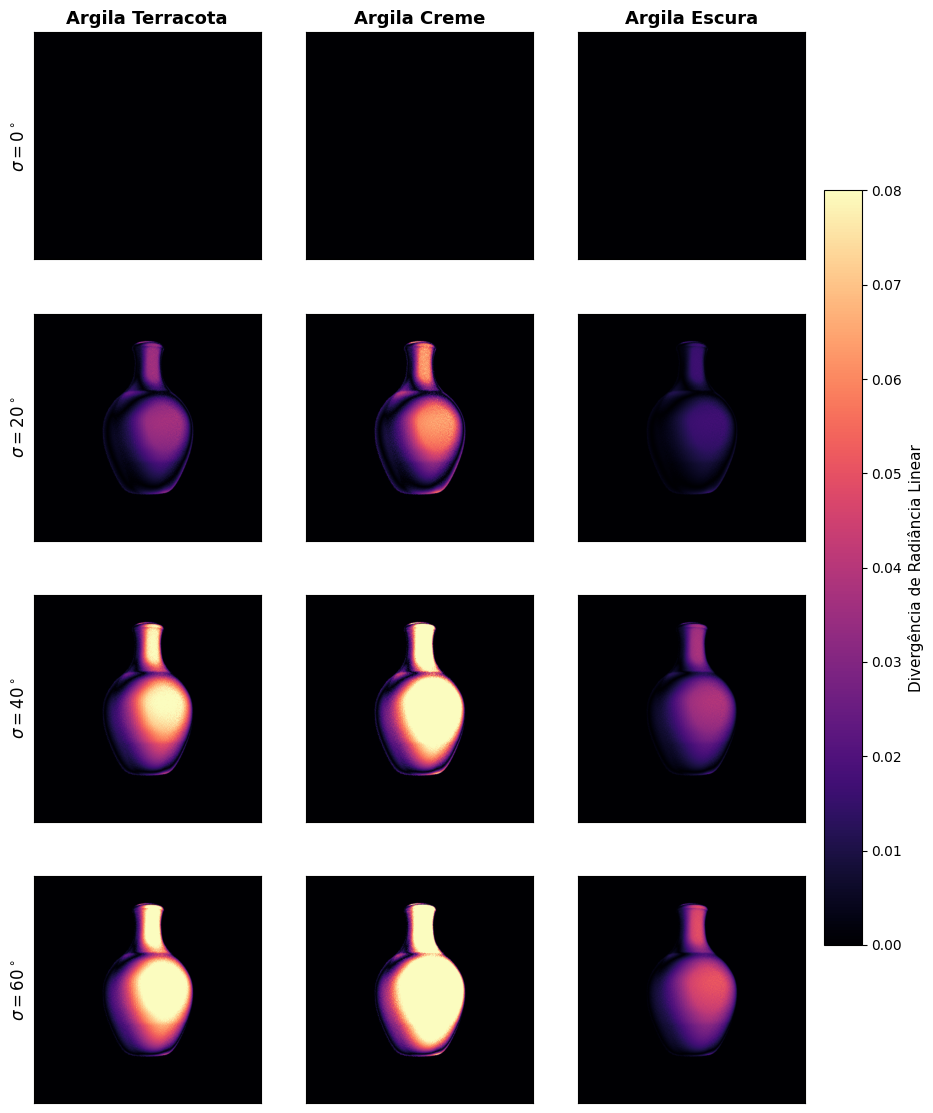

In [10]:
fig, axes = plt.subplots(
    len(sigmas_teste),
    len(materiais_argila),
    figsize=(12, 14),
)

# Loop para gerar os heatmaps de divergência em relação a sigma = 0°
for col_idx, (nome_mat, _) in enumerate(materiais_argila.items()):
    base_lambert = matriz_renders[nome_mat][0.0]

    for row_idx, s in enumerate(sigmas_teste):
        ax = axes[row_idx, col_idx]

        # Diferença absoluta escalar (média dos canais RGB)
        diff = np.abs(matriz_renders[nome_mat][s] - base_lambert)
        diff_gray = np.mean(diff, axis=2)

        # Exibição do Heatmap em mapa de cor magma
        im = ax.imshow(diff_gray, cmap="magma", vmin=0, vmax=0.08)

        if row_idx == 0:
            ax.set_title(f"Argila {nome_mat}", fontsize=13, fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(
                rf"$\sigma = {int(s)}^\circ$", fontsize=12, fontweight="bold"
            )

        ax.set_xticks([])
        ax.set_yticks([])

# Barra de cor lateral unificada
cbar = fig.colorbar(
    im, ax=axes.ravel().tolist(), shrink=0.7, pad=0.02
)
cbar.set_label("Divergência de Radiância Linear", fontsize=11)

plt.savefig("matriz_heatmap_argila.png", dpi=300, bbox_inches="tight")
plt.show()